ONLINE FOOD DELIVERY ANALYSIS

OBJECTIVE

The objective of this project is to analyze food delivery data and identify factors affecting delivery time, customer satisfaction, and ordering patterns.

IMPORTING LIBRARIES

In [10]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sqlalchemy import create_engine


Load Data set

In [11]:
df = pd.read_csv(r"C:\Users\keert\Desktop\online food order\ONLINE_FOOD_DELIVERY_ANALYSIS.csv")
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (100000, 25)


,Order_ID,Customer_ID,Customer_Age,Customer_Gender,City,Area,Restaurant_ID,Restaurant_Name,Cuisine_Type,Order_Date,...,Final_Amount,Payment_Mode,Order_Status,Cancellation_Reason,Delivery_Partner_ID,Delivery_Rating,Restaurant_Rating,Order_Day,Peak_Hour,Profit_Margin
0,ORD000001,CUST6948,19.0,Male,NaN,Central,RES936,Restaurant_29,Chinese,10/20/2024,...,NaN,UPI,Delivered,NaN,DP563,5.0,4.4,Weekend,True,0.13
1,ORD000002,CUST6515,NaN,Female,Chennai,North,RES689,Restaurant_419,Chinese,8/12/2024,...,4849.0,COD,Delivered,NaN,DP369,5.0,4.7,Weekday,True,0.48
2,ORD000003,CUST1765,NaN,Male,Delhi,NaN,RES723,Restaurant_244,Arabian,12/8/2024,...,737.0,Wallet,Delivered,NaN,DP580,4.0,4.9,Weekend,True,0.08
3,ORD000004,CUST2744,NaN,Male,Mumbai,Central,RES951,Restaurant_178,Chinese,10/8/2024,...,NaN,UPI,Cancelled,Late Delivery,DP155,2.0,3.4,Weekday,NaN,0.04
4,ORD000005,CUST4389,57.0,Female,Chennai,South,RES419,Restaurant_262,Chinese,2/4/2024,...,352.0,Card,Delivered,NaN,DP728,2.0,4.4,Weekend,False,0.12


In [12]:


df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 25 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Order_ID             100000 non-null  object 
 1   Customer_ID          100000 non-null  object 
 2   Customer_Age         49907 non-null   float64
 3   Customer_Gender      75144 non-null   object 
 4   City                 83274 non-null   object 
 5   Area                 83315 non-null   object 
 6   Restaurant_ID        100000 non-null  object 
 7   Restaurant_Name      100000 non-null  object 
 8   Cuisine_Type         83115 non-null   object 
 9   Order_Date           98986 non-null   object 
 10  Order_Time           98002 non-null   object 
 11  Delivery_Time_Min    66641 non-null   float64
 12  Distance_km          66530 non-null   float64
 13  Order_Value          66673 non-null   float64
 14  Discount_Applied     83285 non-null   float64
 15  Final_Amount      

Order_ID                   0
Customer_ID                0
Customer_Age           50093
Customer_Gender        24856
City                   16726
Area                   16685
Restaurant_ID              0
Restaurant_Name            0
Cuisine_Type           16885
Order_Date              1014
Order_Time              1998
Delivery_Time_Min      33359
Distance_km            33470
Order_Value            33327
Discount_Applied       16715
Final_Amount           55697
Payment_Mode           19911
Order_Status               0
Cancellation_Reason    90969
Delivery_Partner_ID        0
Delivery_Rating        16523
Restaurant_Rating          0
Order_Day                  0
Peak_Hour              32962
Profit_Margin              0
dtype: int64

DATA CLEANING

HANDLING MISSING VALUES

In [13]:
# Fill numerical columns with median
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Fill categorical columns with mode
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

C:\Users\keert\AppData\Local\Temp\ipykernel_124\2743580984.py:11: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col].fillna(df[col].mode()[0], inplace=True)


Outlier Treatment (IQR Method)

In [14]:
def cap_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    data[column] = np.where(
        data[column] < lower, lower,
        np.where(data[column] > upper, upper, data[column])
    )

for col in ["Delivery_Time_Min", "Order_Value", "Distance_km"]:
    if col in df.columns:
        cap_outliers(df, col)

Correct Invalid Values

In [15]:
# Restrict ratings between 1 and 5
df["Delivery_Rating"] = df["Delivery_Rating"].clip(1,5)
df["Restaurant_Rating"] = df["Restaurant_Rating"].clip(1,5)

# Remove negative order values
df["Order_Value"] = df["Order_Value"].apply(lambda x: np.nan if x < 0 else x)

Feature Engineering Order Day Type

In [16]:
df["Order_Day_Type"] = df["Order_Day"].apply(
    lambda x: "Weekend" if x == "Weekend" else "Weekday"
)

Profit Percentage

In [17]:
df["Profit_Percentage"] = df["Profit_Margin"] * 100

Delivery Category

In [18]:
def delivery_category(time):
    if time <= 30:
        return "Fast"
    elif time <= 60:
        return "Medium"
    else:
        return "Slow"

df["Delivery_Category"] = df["Delivery_Time_Min"].apply(delivery_category)

Exploratory Data Analysis (EDA)

Distribution of Order Value

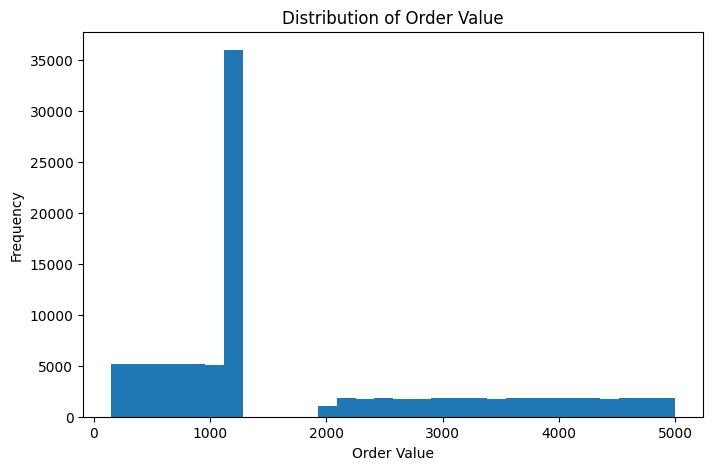

In [19]:
plt.figure(figsize=(8,5))
plt.hist(df["Order_Value"], bins=30)
plt.title("Distribution of Order Value")
plt.xlabel("Order Value")
plt.ylabel("Frequency")
plt.show()

City-wise Orders

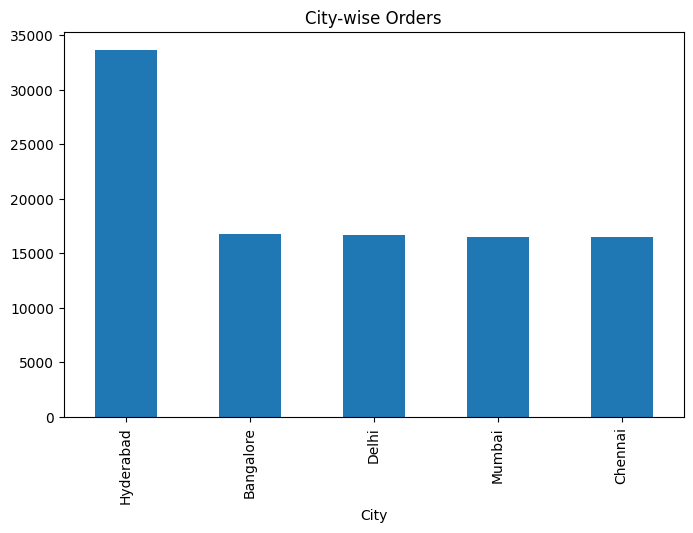

In [20]:
plt.figure(figsize=(8,5))
df["City"].value_counts().plot(kind="bar")
plt.title("City-wise Orders")
plt.show()

Distance vs Delivery Time

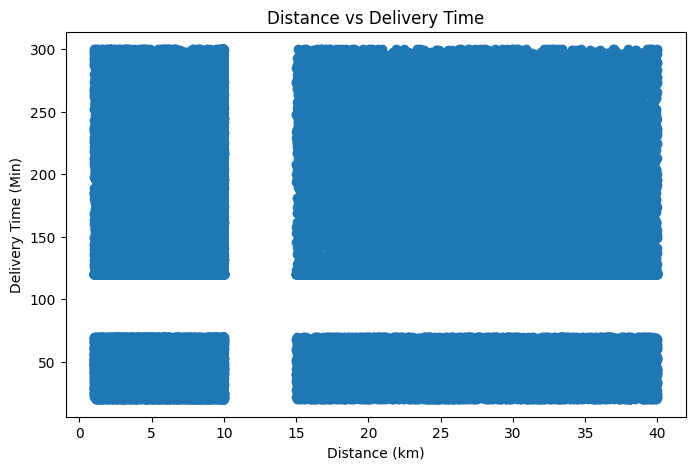

In [21]:
plt.figure(figsize=(8,5))
plt.scatter(df["Distance_km"], df["Delivery_Time_Min"])
plt.xlabel("Distance (km)")
plt.ylabel("Delivery Time (Min)")
plt.title("Distance vs Delivery Time")
plt.show()

Correlation Heatmap

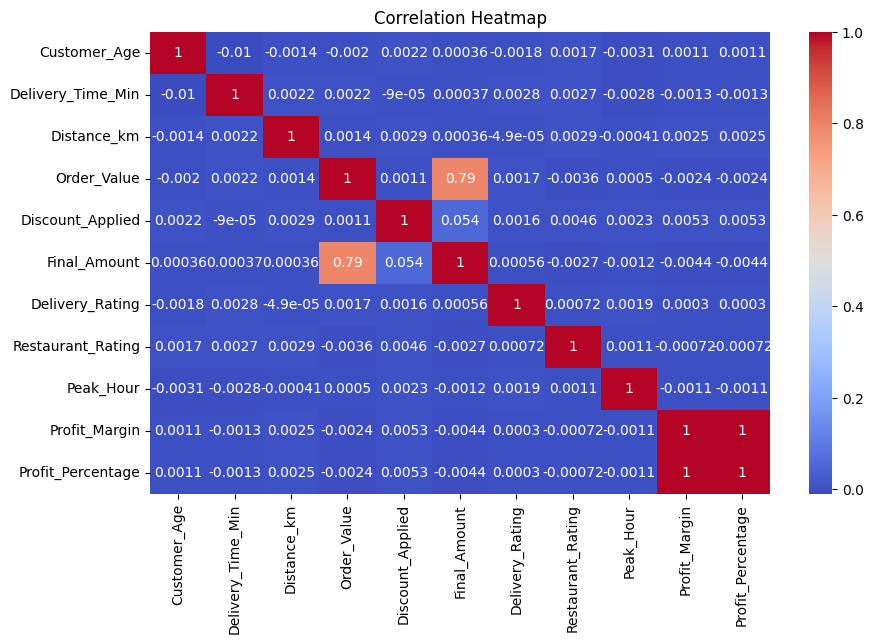

In [22]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

Analyst Tasks

In [23]:
from sqlalchemy import create_engine
import pandas as pd

username = "root"
password = "12345"
host = "localhost"
database = "food_delivery"

engine = create_engine(
    f"mysql+pymysql://{username}:{password}@{host}/{database}"
)

# Actually test connection
try:
    with engine.connect() as connection:
        print("Connection Successful!")
except Exception as e:
    print("Connection Failed:")
    print(e)

Connection Successful!


In [24]:
df.to_sql("food_orders", con=engine, if_exists="replace", index=False)
print("Data uploaded successfully")

Data uploaded successfully


EDA AND ANALYTICS

In [25]:
print(pd.read_sql("DESCRIBE food_orders;", engine))

                  Field        Type Null Key Default Extra
0              Order_ID        text  YES        None      
1           Customer_ID        text  YES        None      
2          Customer_Age      double  YES        None      
3       Customer_Gender        text  YES        None      
4                  City        text  YES        None      
5                  Area        text  YES        None      
6         Restaurant_ID        text  YES        None      
7       Restaurant_Name        text  YES        None      
8          Cuisine_Type        text  YES        None      
9            Order_Date        text  YES        None      
10           Order_Time        text  YES        None      
11    Delivery_Time_Min      double  YES        None      
12          Distance_km      double  YES        None      
13          Order_Value      double  YES        None      
14     Discount_Applied      double  YES        None      
15         Final_Amount      double  YES        None    

Top Spending Customer

In [26]:
query = """
SELECT Customer_ID,
       SUM(Final_Amount) AS total_spent
FROM food_orders
GROUP BY Customer_ID
ORDER BY total_spent DESC
LIMIT 5;
"""
print(pd.read_sql(query, engine))

  Customer_ID  total_spent
0    CUST3471      44379.0
1    CUST4431      43825.0
2    CUST1968      42407.0
3    CUST6252      42207.0
4    CUST1606      42185.0


Age Group vs Order Value

In [27]:
query = """
SELECT 
CASE 
    WHEN Customer_Age < 25 THEN 'Under 25'
    WHEN Customer_Age BETWEEN 25 AND 40 THEN '25-40'
    ELSE '40+'
END AS age_group,
AVG(Final_Amount) AS avg_order_value
FROM food_orders
GROUP BY age_group;
"""
print(pd.read_sql(query, engine))

  age_group  avg_order_value
0  Under 25      1509.471155
1     25-40      1513.087601
2       40+      1512.609157


Weekend vs Weekday Patterns

In [28]:
query = """
SELECT Order_Day_Type,
       COUNT(*) AS total_orders
FROM food_orders
GROUP BY Order_Day_Type;
"""
print(pd.read_sql(query, engine))

  Order_Day_Type  total_orders
0        Weekend         28630
1        Weekday         71370


In [29]:
print(pd.read_sql("SELECT Order_Date FROM food_orders LIMIT 5;", engine))

   Order_Date
0  10/20/2024
1   8/12/2024
2   12/8/2024
3   10/8/2024
4    2/4/2024


Monthly Revenue Trend

      month     revenue
0   2024-01  12782792.0
1   2024-02  11867552.0
2   2024-03  12546352.0
3   2024-04  12285333.0
4   2024-05  12722431.0
5   2024-06  12486665.0
6   2024-07  14590655.0
7   2024-08  12483141.0
8   2024-09  12477088.0
9   2024-10  12526182.0
10  2024-11  12392000.0
11  2024-12  12108207.0


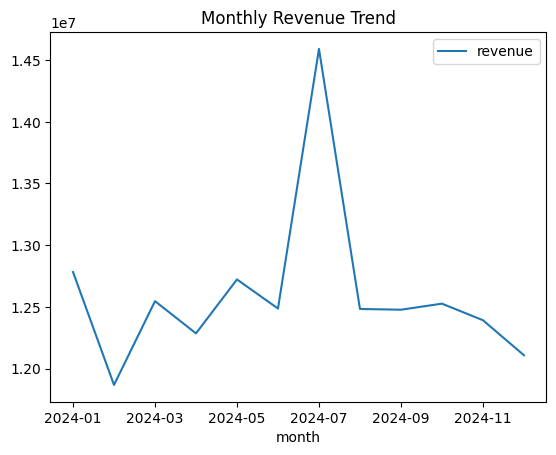

In [30]:
query = """
SELECT DATE_FORMAT(
           STR_TO_DATE(Order_Date, '%%m/%%d/%%Y'),
           '%%Y-%%m'
       ) AS month,
       SUM(Final_Amount) AS revenue
FROM food_orders
GROUP BY month
ORDER BY month;
"""

monthly = pd.read_sql(query, engine)
print(monthly)

monthly.plot(x='month', y='revenue', kind='line')
plt.title("Monthly Revenue Trend")
plt.show()

Impact of Discounts on Profit

In [31]:
query = """
SELECT 
SUM(Order_Value) AS total_order_value,
SUM(Discount_Applied) AS total_discount,
SUM(Final_Amount) AS total_revenue,
AVG(Profit_Margin) AS avg_profit_margin
FROM food_orders;
"""
print(pd.read_sql(query, engine))

   total_order_value  total_discount  total_revenue  avg_profit_margin
0        178694279.0       8659230.0    151268398.0           0.150362


High-Revenue Cities & Cuisines

In [32]:
query = """
SELECT City,
       Cuisine_Type,
       SUM(Final_Amount) AS revenue
FROM food_orders
GROUP BY City, Cuisine_Type
ORDER BY revenue DESC;
"""
print(pd.read_sql(query, engine))

         City Cuisine_Type     revenue
0   Hyderabad       Indian  17083528.0
1     Chennai       Indian   8595082.0
2   Bangalore       Indian   8536877.0
3   Hyderabad      Arabian   8480711.0
4   Hyderabad      Mexican   8462045.0
5       Delhi       Indian   8452791.0
6   Hyderabad      Chinese   8413902.0
7      Mumbai       Indian   8396095.0
8   Hyderabad      Italian   8342883.0
9   Bangalore      Mexican   4274266.0
10  Bangalore      Chinese   4224786.0
11  Bangalore      Arabian   4217194.0
12    Chennai      Chinese   4183111.0
13      Delhi      Chinese   4177891.0
14     Mumbai      Chinese   4169896.0
15  Bangalore      Italian   4165619.0
16     Mumbai      Arabian   4161315.0
17      Delhi      Mexican   4157264.0
18    Chennai      Mexican   4149185.0
19     Mumbai      Mexican   4138333.0
20      Delhi      Arabian   4109798.0
21      Delhi      Italian   4108469.0
22    Chennai      Arabian   4108013.0
23    Chennai      Italian   4086839.0
24     Mumbai      Italia

Average Delivery Time by City

In [33]:
query = """
SELECT City,
       AVG(Delivery_Time_Min) AS avg_delivery_time
FROM food_orders
GROUP BY City;
"""
print(pd.read_sql(query, engine))

        City  avg_delivery_time
0  Hyderabad         125.070872
1    Chennai         124.549423
2      Delhi         124.896376
3     Mumbai         125.937246
4  Bangalore         124.373297


Distance vs Delivery Delay

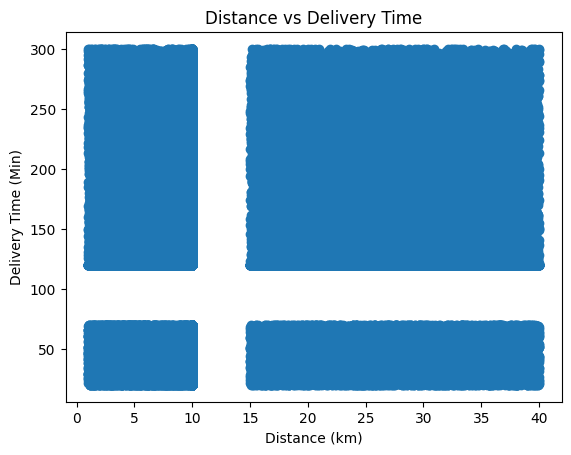

In [34]:
query = """
SELECT Distance_km, Delivery_Time_Min
FROM food_orders;
"""
data = pd.read_sql(query, engine)

plt.scatter(data['Distance_km'], data['Delivery_Time_Min'])
plt.xlabel("Distance (km)")
plt.ylabel("Delivery Time (Min)")
plt.title("Distance vs Delivery Time")
plt.show()

Delivery Rating vs Delivery Time

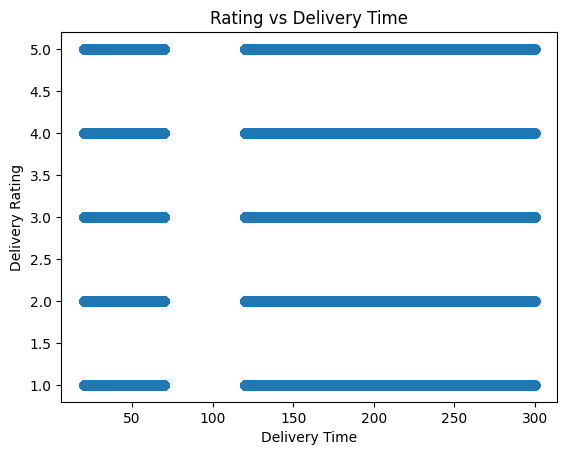

In [35]:
query = """
SELECT Delivery_Time_Min, Delivery_Rating
FROM food_orders;
"""
data = pd.read_sql(query, engine)

plt.scatter(data['Delivery_Time_Min'], data['Delivery_Rating'])
plt.xlabel("Delivery Time")
plt.ylabel("Delivery Rating")
plt.title("Rating vs Delivery Time")
plt.show()

Top-Rated Restaurants

In [36]:
query = """
SELECT Restaurant_Name,
       AVG(Restaurant_Rating) AS avg_rating
FROM food_orders
GROUP BY Restaurant_Name
ORDER BY avg_rating DESC
LIMIT 5;
"""
print(pd.read_sql(query, engine))

  Restaurant_Name  avg_rating
0  Restaurant_101    4.325843
1    Restaurant_1    4.313472
2  Restaurant_162    4.308242
3  Restaurant_496    4.304433
4  Restaurant_355    4.301657


Cancellation Rate by Restaurant

In [37]:
query = """
SELECT Restaurant_Name,
       SUM(CASE WHEN Order_Status = 'Cancelled' THEN 1 ELSE 0 END)
       / COUNT(*) * 100 AS cancellation_rate
FROM food_orders
GROUP BY Restaurant_Name;
"""
print(pd.read_sql(query, engine))

    Restaurant_Name  cancellation_rate
0     Restaurant_29             9.6618
1    Restaurant_419            10.9890
2    Restaurant_244            15.0943
3    Restaurant_178            14.0541
4    Restaurant_262            15.6566
..              ...                ...
495  Restaurant_180            13.6364
496  Restaurant_350            17.3709
497  Restaurant_404            13.4328
498    Restaurant_7            13.7755
499  Restaurant_295            16.1905

[500 rows x 2 columns]


Cuisine-wise Performance

In [38]:
query = """
SELECT Cuisine_Type,
       COUNT(*) AS total_orders,
       SUM(Final_Amount) AS revenue
FROM food_orders
GROUP BY Cuisine_Type
ORDER BY revenue DESC;
"""
print(pd.read_sql(query, engine))

  Cuisine_Type  total_orders     revenue
0       Indian         33570  51064373.0
1      Mexican         16602  25181093.0
2      Chinese         16651  25169586.0
3      Arabian         16658  25077031.0
4      Italian         16519  24776315.0


Peak Hour Demand

In [39]:
query = """
SELECT Peak_Hour,
       COUNT(*) AS total_orders
FROM food_orders
GROUP BY Peak_Hour
ORDER BY total_orders DESC;
"""
print(pd.read_sql(query, engine))

   Peak_Hour  total_orders
0          0         66547
1          1         33453


Payment Mode Preferences

In [40]:
query = """
SELECT Payment_Mode,
       COUNT(*) AS usage_count
FROM food_orders
GROUP BY Payment_Mode;
"""
print(pd.read_sql(query, engine))

  Payment_Mode  usage_count
0          UPI        19932
1          COD        19977
2       Wallet        20086
3         Card        40005


Cancellation Reason Analysis

In [41]:
query = """
SELECT Cancellation_Reason,
       COUNT(*) AS total
FROM food_orders
WHERE Order_Status = 'Cancelled'
GROUP BY Cancellation_Reason
ORDER BY total DESC;
"""
print(pd.read_sql(query, engine))

  Cancellation_Reason  total
0       Late Delivery   9064
1  Customer Cancelled   2993
2    Restaurant Issue   2979


CONCLUSION

This project analyzed online food delivery data to understand customer behavior, delivery performance, and restaurant efficiency. Through data cleaning and exploratory data analysis, key patterns in orders, delivery time, and cancellations were identified. The insights help improve delivery operations, customer satisfaction, and business decision-making. Overall, data analytics enables food delivery platforms to optimize their services and performance.
